#  Notebook 03 — Customer Segmentation (RFM Analysis)
## Goal: Segment customers based on buying behavior
**Method:** RFM — Recency, Frequency, Monetary
**Business Value:** Identify Champions, Loyal, At Risk and Lost customers

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

master =pd.read_csv("../data/processed/master_clean.csv")

master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'],errors='coerce')

print('Data Loaded')
print(f" Shape: {master.shape[0]:,} rows x {master.shape[1]} columns")

Data Loaded
 Shape: 119,143 rows x 28 columns


## Question 1  Filter delivered orders

In [17]:
# Business Question: Who are we actually analyzing?

rfm_df =master[master['order_status'] == 'delivered'].copy()
print(f" Delivered orders: {rfm_df['order_id'].nunique():,}")
print(f" Unique customers: {rfm_df['customer_unique_id'].nunique():,}")

 Delivered orders: 96,478
 Unique customers: 93,358


## Question 2 Set reference date

In [18]:
# Set your reference point
# Business question: "Recency means 'how many days AGO did they buy?' — but AGO from WHEN exactly?"


reference_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print( f" Reference_date: {reference_date.date()}")

 Reference_date: 2018-08-30


##  Question 3 Calculate R, F, M values

In [19]:
rfm = rfm_df.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', 
                 lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

print(" RFM values calculated")
print(f" \n sample - first 5 customers")
print(rfm.head())

print(f" \n RFM Statistics:")
print(rfm[['recency','frequency','monetary']].describe().round(2))

 RFM values calculated
 
 sample - first 5 customers
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
 
 RFM Statistics:
        recency  frequency   monetary
count  93358.00   93358.00   93358.00
mean     237.94       1.03     212.96
std      152.59       0.21     646.22
min        1.00       1.00       0.00
25%      114.00       1.00      63.83
50%      219.00       1.00     113.14
75%      346.00       1.00     202.64
max      714.00      15.00  109312.64


##  Score every customer 1 to 5

In [20]:

rfm['R_Score'] = pd.qcut(rfm['recency'],
                          q=5, labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5])


rfm['M_Score'] = pd.qcut(rfm['monetary'],
                          q=5, labels=[1,2,3,4,5])

# Convert to integers
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)


rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(" Scores assigned!")
print(rfm[['recency','R_Score','frequency','F_Score',
           'monetary','M_Score','RFM_Score']].head(10))

 Scores assigned!
   recency  R_Score  frequency  F_Score  monetary  M_Score  RFM_Score
0      112        4          1        1    141.90        4          9
1      115        4          1        1     27.19        1          6
2      537        1          1        1     86.22        2          4
3      321        2          1        1     43.62        1          4
4      288        2          1        1    196.89        4          7
5      146        4          1        1    166.98        4          9
6      132        4          1        1     35.38        1          6
7      183        3          1        1    838.36        5          9
8      543        1          1        1    150.12        4          6
9      170        4          1        1    129.76        3          8


##  Question 5  Label each customer with a segment name

In [21]:

def assign_segment(row):
    r=row['R_Score']
    f=row['F_Score']
    m=row['M_Score']

    if r>=4 and f>=4 and m>=4:
        return 'Champion'
    elif r>=3 and f>=3:
        return'Loyal Customer'
    elif r>=4 and f<=2:
        return 'New Customers'
    elif r>=3 and f<=2 and m >=3:
        return 'Potential Loyalist'
    elif r<=2 and f>=3:
        return 'At Risk'
    elif r<=2 and f<=2 and m<=2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment']= rfm.apply(assign_segment, axis=1)

print("\n segments assigned")
print("\n segment Distribution:")
print(rfm['segment'].value_counts())


 segments assigned

 segment Distribution:
segment
Loyal Customer        27323
At Risk               22230
New Customers         14984
Needs Attention       11736
Champion               6462
Lost                   6279
Potential Loyalist     4344
Name: count, dtype: int64


##  Question 6  Visualize the segments

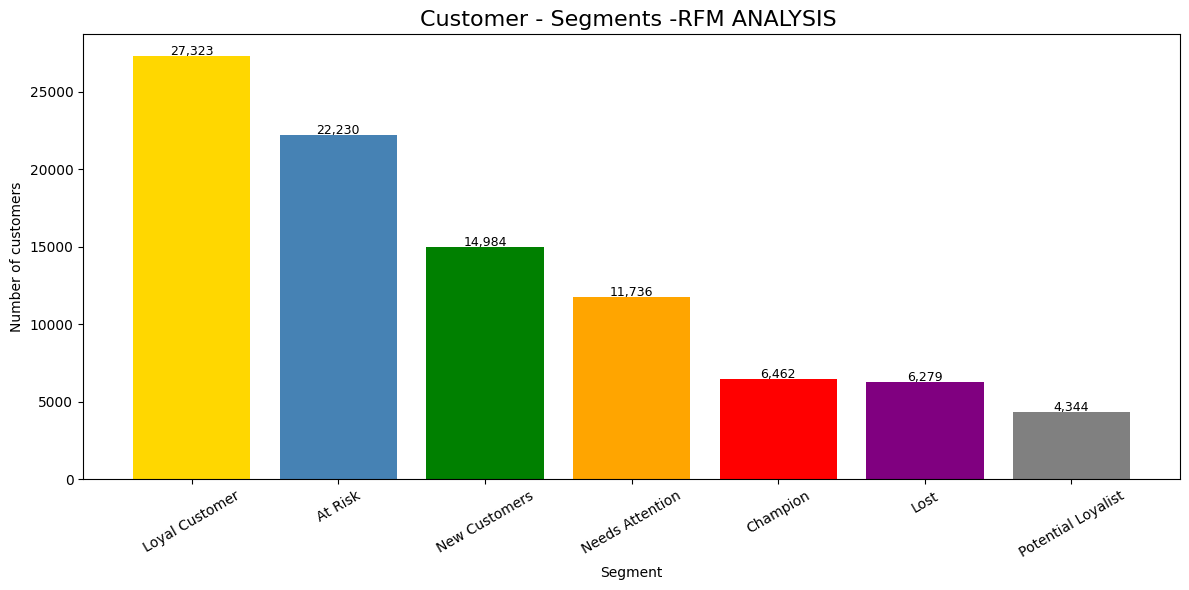


 Revenue by Segment:
  At Risk              →  4,770,436
  Loyal Customer       →  4,554,896
  New Customers        →  3,062,988
  Needs Attention      →  3,038,058
  Champion             →  2,871,304
  Potential Loyalist   →  1,230,010
  Lost                 →  354,253


In [22]:
segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['Segment','Count']

plt.figure(figsize=(12,6))
colors=['gold','steelblue','green','orange','red','purple','grey']
bars = plt.bar(segment_counts['Segment'],
              segment_counts['Count'],color=colors)

plt.title('Customer - Segments -RFM ANALYSIS ', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Number of customers')
plt.xticks(rotation=30)

for bar,count in zip(bars,segment_counts['Count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{count:,}', ha='center',fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/rfm_segmenting.png', dpi=150)
plt.show()

segment_revenue =rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
print("\n Revenue by Segment:")
for seg, rev in segment_revenue.items():
    print(f"  {seg:20s} →  {rev:,.0f}")

##  Question 7 Business recommendations

In [14]:
# QUESTION 7 Business Recommendations

champion_count = len(rfm[rfm['segment'] == 'Champion'])
at_risk_count  = len(rfm[rfm['segment'] == 'At Risk'])
lost_count     = len(rfm[rfm['segment'] == 'Lost'])
new_count      = len(rfm[rfm['segment'] == 'New Customer'])
total          = len(rfm)

print("=" * 55)
print(" RFM BUSINESS RECOMMENDATIONS")
print("=" * 55)
print(f"""
    CHAMPIONS ({champion_count:,} customers — {champion_count/total*100:.1f}%)
   → Reward with exclusive offers and early access
   → Ask for referrals and reviews
   → They are your brand ambassadors — protect them

      AT RISK ({at_risk_count:,} customers — {at_risk_count/total*100:.1f}%)
   → Launch win-back campaigns immediately
   → Send personalized discount based on past purchases
   → These were valuable — every one saved = direct revenue

    LOST ({lost_count:,} customers — {lost_count/total*100:.1f}%)
   → Low priority — expensive to reactivate
   → Only target with very aggressive offers
   → Redirect budget to New and At Risk segments

    NEW CUSTOMERS ({new_count:,} customers — {new_count/total*100:.1f}%)
   → First 30 days experience is everything
   → Send onboarding content and welcome offers
   → Goal: convert them to Loyal before they go cold
""")

 RFM BUSINESS RECOMMENDATIONS

    CHAMPIONS (6,462 customers — 6.9%)
   → Reward with exclusive offers and early access
   → Ask for referrals and reviews
   → They are your brand ambassadors — protect them

      AT RISK (22,230 customers — 23.8%)
   → Launch win-back campaigns immediately
   → Send personalized discount based on past purchases
   → These were valuable — every one saved = direct revenue

    LOST (6,279 customers — 6.7%)
   → Low priority — expensive to reactivate
   → Only target with very aggressive offers
   → Redirect budget to New and At Risk segments

    NEW CUSTOMERS (0 customers — 0.0%)
   → First 30 days experience is everything
   → Send onboarding content and welcome offers
   → Goal: convert them to Loyal before they go cold

